In [1]:
import pandas as pd
import os
from random import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

os.environ["KERAS_BACKEND"] = "torch" 

import keras
from keras import layers, models, ops
from keras.callbacks import EarlyStopping
from datetime import timedelta
from keras.models import load_model

In [2]:
os.chdir("..")

In [3]:
# from src.feature_engineering import apply_label_encoding_nn

In [4]:
train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

# On supprime l'année 2013 car on va utiliser les lags à un an
def delete_2013(df):
    return df[df['year'] != 2013]

train = delete_2013(train)
test = delete_2013(test)

In [5]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'store_type', 'cluster', 'oil_price', 'oil_price_trend_30',
       'oil_price_trend_60', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
       'oil_price_lag_8w_trend_60', 'holiday_type', 'is_holiday_local',
       'is_holiday_regional', 'is_holiday_national', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_payday', 'month_sin', 'month_cos', 'day_sin',
       'day_cos', 'is_earthquake_impact', 'days_to_christmas', 'sales_lag_1',
       'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 'sales_lag_14',
       'sales_lag_28', 'sales_lag_56', 'sales_lag_364', 'rolling_mean_7',
       'rolling_mean_28', 'log_sales', 'rolling_std_7', 'is_store_closed',
       'is_family_unactive', 'is_store_closed_lag_1',
       'is_family_unactive_lag_1'],
      dtype='object')

In [7]:
train.isnull().sum()

id                           0
date                         0
store_nbr                    0
family                       0
sales                        0
onpromotion                  0
city                         0
state                        0
store_type                   0
cluster                      0
oil_price                    0
oil_price_trend_30           0
oil_price_trend_60           0
oil_price_lag_8w             0
oil_price_lag_8w_trend_30    0
oil_price_lag_8w_trend_60    0
holiday_type                 0
is_holiday_local             0
is_holiday_regional          0
is_holiday_national          0
day_of_week                  0
month                        0
year                         0
is_weekend                   0
is_payday                    0
month_sin                    0
month_cos                    0
day_sin                      0
day_cos                      0
is_earthquake_impact         0
days_to_christmas            0
sales_lag_1                  0
sales_la

In [15]:
def time_series_expanding_window(df, n_test_days=56, n_splits=5):
    print(f"Preparation de la validation croisee : {n_splits} splits de {n_test_days} jours.")
    
    unique_dates = np.sort(df['date'].unique())
    total_days = len(unique_dates)
    
    if (n_splits * n_test_days) >= total_days:
        raise ValueError(f"Pas assez de donnees pour {n_splits} splits.")

    splits = []
    
    for i in range(n_splits):
        end_test_idx = total_days - (i * n_test_days)
        start_test_idx = end_test_idx - n_test_days
        
        train_dates = unique_dates[:start_test_idx]
        val_dates = unique_dates[start_test_idx:end_test_idx]
        
        train_indices = df[df['date'].isin(train_dates)].index
        val_indices = df[df['date'].isin(val_dates)].index
        
        splits.insert(0, (train_indices, val_indices))
        
        print(f"Split {n_splits - i}: Train jusqu'au {str(train_dates[-1])[:10]}, "
              f"Val du {str(val_dates[0])[:10]} au {str(val_dates[-1])[:10]}")

    return splits


def apply_label_encoding_nn(df, cols, encoders_dict=None):
    df_encoded = df.copy()
    is_train = encoders_dict is None
    new_encoders = {}

    print(f"Shape initiale du DataFrame: {df_encoded.shape}")

    for col in cols:
        df_encoded[col] = df_encoded[col].astype(str)

        if is_train:
            le = LabelEncoder()
            
            # Construire le vocabulaire
            vocab = df_encoded[col].astype(str).unique().tolist()
            vocab.append("__UNK__")
            
            # Fit sur le vocabulaire
            le.fit(vocab)
            
            # Transform uniquement les vraies données
            df_encoded[f"label_{col}"] = le.transform(df_encoded[col])
            
            new_encoders[col] = le

            n_unique = len(le.classes_)
            emb_dim = min(50, (n_unique + 1) // 2)
            print(f"[TRAIN] Col: {col} | Uniques: {n_unique} | Embedding dim suggere: {emb_dim}")

        else:
            if col not in encoders_dict:
                print(f"Colonne {col} absente du dictionnaire d'encodeurs.")
                continue
                
            le = encoders_dict[col]
            
            # Gestion des catégories inconnues dans le test
            # On mappe les nouvelles valeurs vers une catégorie spécifique ou on utilise transform
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else "__UNK__")
            
            df_encoded[f'label_{col}'] = le.transform(df_encoded[col])
            print(f"[TEST] Col: {col} | Encodage applique avec succès")

        df_encoded = df_encoded.drop(columns=[col])
    
    print(f"Shape finale du DataFrame: {df_encoded.shape}")

    return df_encoded, (new_encoders if is_train else encoders_dict)


def apply_scaling_nn(df, cols_to_scale, scalers_dict=None):
    """
    Applique le StandardScaling sur les colonnes numeriques.
    Gere le fit sur train et le transform sur test pour eviter le leakage.
    """
    df_scaled = df.copy()
    is_train = scalers_dict is None
    new_scalers = {}

    for col in cols_to_scale:
        if col not in df_scaled.columns:
            continue
            
        if is_train:
            # Mode APPRENTISSAGE
            scaler = StandardScaler()
            # Reshape necessaire pour sklearn (-1, 1)
            df_scaled[col] = scaler.fit_transform(df_scaled[[col]])
            new_scalers[col] = scaler
            print(f"[TRAIN] Scaling de {col} : Moyenne={scaler.mean_[0]:.2f}, Ecart-type={scaler.scale_[0]:.2f}")
        else:
            # Mode APPLICATION
            if col in scalers_dict:
                scaler = scalers_dict[col]
                df_scaled[col] = scaler.transform(df_scaled[[col]])
            else:
                print(f"Scaler manquant pour {col}")

    return df_scaled, (new_scalers if is_train else scalers_dict)


def create_3d_tensors(df, cat_cols, holiday_cols, window_past=90, window_future=56, step=1):

    X_past_final, X_future_final, Y_final, weights_final = [], [], [], []
    cat_values = {col: [] for col in cat_cols}

    # cols_past = [
    #     'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
    #     'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
    #     'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
    #     'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1',
    #     'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend', 'is_payday',
    #     "is_earthquake_impact", 'is_holiday_local', 'is_holiday_regional', 
    #     'is_holiday_national', 'days_to_christmas'
    # ]
    # cols_future = [
    #     'onpromotion', 'is_holiday_local', 'is_holiday_regional', 
    #     'is_holiday_national', 'month_sin', 'month_cos', 'day_sin', 
    #     'day_cos', 'is_weekend', 'is_payday', 'days_to_christmas', 
    #     "is_earthquake_impact"
    # ]

    cols_past = ['onpromotion', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
        'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
        'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1'] + holiday_cols
    
    cols_future = ['onpromotion'] + holiday_cols

    grouped = df.groupby(['label_store_nbr', 'label_family'])

    for name, group in grouped:

        group_values = group.sort_values('date')
        past_arr = group_values[cols_past].values
        future_arr = group_values[cols_future].values
        target_arr = group_values['log_sales'].values

        # 1 si ouvert/actif, 0 sinon
        weight_arr = ((group_values['is_store_closed'] == 0) & 
                      (group_values['is_family_unactive'] == 0)).astype(float).values
        
        static_cats = {col: group_values[f'label_{col}'].iloc[0] for col in cat_cols}

        n_obs = len(group_values)
        for i in range(0, n_obs - window_past - window_future + 1, step):

            X_past_final.append(past_arr[i : i + window_past])
            X_future_final.append(future_arr[i + window_past : i + window_past + window_future])
            Y_final.append(target_arr[i + window_past : i + window_past + window_future])
            weights_final.append(weight_arr[i + window_past : i + window_past + window_future])
            
            for col in cat_cols:
                cat_values[col].append(static_cats[col])

    X_list = [
        np.array(X_past_final, dtype='float32'), 
        np.array(X_future_final, dtype='float32')
    ]

    for col in cat_cols:
        X_list.append(np.array(cat_values[col], dtype='int32'))

    return X_list, np.array(Y_final, dtype='float32'), np.array(weights_final, dtype='float32')


def build_mimo_lstm(shape_past, shape_future, encoders, cat_cols, window_future=56):
    # Entrées pour les variables catégorielles avec embeddings
    cat_inputs = []
    cat_embeddings = []
    
    for col in cat_cols:
        n_unique = len(encoders[col].classes_)
        emb_dim = min(50, (n_unique + 1) // 2)
        
        inp = layers.Input(shape=(1,), name=f"input_{col}")
        emb = layers.Embedding(input_dim=n_unique, output_dim=emb_dim, name=f"emb_{col}")(inp)
        emb = layers.Flatten()(emb)
        
        cat_inputs.append(inp)
        cat_embeddings.append(emb)
    
    concat_cats = layers.Concatenate()(cat_embeddings)
    # Répéter pour les 56 jours du futur
    cats_repeated = layers.RepeatVector(window_future)(concat_cats)

    # Branche passé (LSTM)
    input_past = layers.Input(shape=shape_past, name="input_past")
    lstm_out = layers.LSTM(64, return_sequences=False)(input_past)
    past_repeated = layers.RepeatVector(window_future)(lstm_out)

    # Branche future (Contexte)
    input_future = layers.Input(shape=shape_future, name="input_future")

    # Fusion et sortie
    combined = layers.Concatenate()([past_repeated, input_future, cats_repeated])
    
    # Couches denses appliquées à chaque pas de temps
    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(combined)
    x = layers.TimeDistributed(layers.Dense(1))(x)

    # Reshape pour passer de (batch, 56, 1) à (batch, 56)
    output = layers.Reshape((window_future,))(x)

    model = models.Model(inputs=[input_past, input_future] + cat_inputs, outputs=output)
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Dans cette version suivante, on ajoute :
# - Une deuxième couche LSTM dans la branche passé pour capturer des patterns plus complexes.
# - Des couches denses supplémentaires dans le décodeur pour une meilleure capacité d'apprentissage.
# - Des Dropout pour réduire le surapprentissage.

def build_mimo_lstm_advanced(shape_past, shape_future, encoders, cat_cols, window_future=56, dropout=0.2):

    # Embeddings (Identité)
    cat_inputs, cat_embeddings = [], []
    for col in cat_cols:
        n_unique = len(encoders[col].classes_)
        emb_dim = min(50, (n_unique + 1) // 2)
        inp = layers.Input(shape=(1,), name=f"input_{col}")
        emb = layers.Embedding(input_dim=n_unique, output_dim=emb_dim)(inp)
        emb = layers.Flatten()(emb)
        cat_inputs.append(inp)
        cat_embeddings.append(emb)
    
    concat_cats = layers.Concatenate()(cat_embeddings)
    cats_repeated = layers.RepeatVector(window_future)(concat_cats)

    # Branche Passé : Double LSTM
    input_past = layers.Input(shape=shape_past, name="input_past")
    
    # Premier LSTM : On garde les séquences pour que le suivant puisse "lire"
    x_past = layers.LSTM(64, return_sequences=True)(input_past)
    x_past = layers.Dropout(dropout)(x_past)
    
    # Second LSTM : On extrait le résumé final
    lstm_out = layers.LSTM(32, return_sequences=False)(x_past)
    lstm_out = layers.Dropout(dropout)(lstm_out)
    
    # On répète le résumé pour chaque pas futur
    past_repeated = layers.RepeatVector(window_future)(lstm_out)

    # Branche Future & Fusion
    input_future = layers.Input(shape=shape_future, name="input_future")

    combined = layers.Concatenate()([past_repeated, input_future, cats_repeated])
    
    # Décodeur Dense
    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(combined)
    x = layers.TimeDistributed(layers.Dropout(dropout))(x)
    x = layers.TimeDistributed(layers.Dense(32, activation='relu'))(x) # Couche supplémentaire
    
    x = layers.TimeDistributed(layers.Dense(1))(x) 

    output = layers.Reshape((window_future,))(x)

    model = models.Model(inputs=[input_past, input_future] + cat_inputs, outputs=output)
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def evaluate_model_simple(y_true, y_pred, weights):
    y_pred_clipped = np.maximum(y_pred, 0)
    n_active = np.sum(weights)
    
    if n_active == 0: 
        return {"mae": np.nan, "rmse": np.nan, "rmsle": np.nan}
    
    mae = np.sum(np.abs(y_true - y_pred_clipped) * weights) / n_active
    rmse = np.sqrt(np.sum(((y_true - y_pred_clipped) ** 2) * weights) / n_active)
    
    log_true = np.log1p(np.maximum(y_true, 0))
    log_pred = np.log1p(y_pred_clipped)
    rmsle = np.sqrt(np.sum(((log_true - log_pred) ** 2) * weights) / n_active)
    
    return {"mae": mae, "rmse": rmse, "rmsle": rmsle}

One hot encoder la variable holiday type (seule variable catégorielle dynamique et pas leakage car les modalités sont exhaustives donc on traite en amont):

In [9]:
from sklearn.preprocessing import OneHotEncoder

def apply_one_hot_encoding(df_train, df_val, col='holiday_type'):

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Fit sur le train et transformation
    train_encoded = encoder.fit_transform(df_train[[col]])
    train_dummy_df = pd.DataFrame(
        train_encoded, 
        columns=encoder.get_feature_names_out([col]),
        index=df_train.index
    )
    
    # Transformation du val
    val_encoded = encoder.transform(df_val[[col]])
    val_dummy_df = pd.DataFrame(
        val_encoded, 
        columns=encoder.get_feature_names_out([col]),
        index=df_val.index
    )
    
    # Concatenation et suppression de l'ancienne colonne
    df_train_final = pd.concat([df_train.drop(columns=[col]), train_dummy_df], axis=1)
    df_val_final = pd.concat([df_val.drop(columns=[col]), val_dummy_df], axis=1)
    
    new_cols = list(encoder.get_feature_names_out([col]))
    
    return df_train_final, df_val_final, new_cols

train, test, holiday_cols = apply_one_hot_encoding(train, test, col='holiday_type')

Modèle simple :

In [16]:
cv_splits = time_series_expanding_window(train, n_test_days=56, n_splits=3)
results_cv = []

early_stop = EarlyStopping(
    monitor='loss', # On surveille la perte sur le train (car la val_loss sur 1 seul bloc est instable)
    patience=2,     # Si pendant 2 époques ça ne s'améliore pas, on arrête
    restore_best_weights=True
)

cols_to_scale = [
    'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30', 
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 
    'sales_lag_7', 'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 
    'rolling_mean_28', 'rolling_std_7'
]

cols_to_encode = ['family', 'store_nbr', 'cluster', 'store_type']


for i, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n--- SPLIT {i+1} ---")
    
    df_fold_train = train.loc[train_idx].copy()
    df_fold_val = train.loc[val_idx].copy()
    
    df_fold_train, encoders = apply_label_encoding_nn(df_fold_train, cols_to_encode)
    df_fold_val, _ = apply_label_encoding_nn(df_fold_val, cols_to_encode, encoders_dict=encoders)
    df_fold_train, scalers = apply_scaling_nn(df_fold_train, cols_to_scale)
    df_fold_val, _ = apply_scaling_nn(df_fold_val, cols_to_scale, scalers_dict=scalers)
    
    # Train tensors (jouer sur step pour sauver de la RAM si besoin)
    X_train_list, y_train_3d, w_train_3d = create_3d_tensors(df_fold_train, cols_to_encode, holiday_cols=holiday_cols, step=7)
    
    # Val tensors avec contexte
    last_90 = df_fold_train.groupby(['label_store_nbr', 'label_family']).tail(90)
    df_val_ctx = pd.concat([last_90, df_fold_val]).sort_values(['label_store_nbr', 'label_family', 'date'])
    X_val_list, y_val_3d, w_val_3d = create_3d_tensors(df_val_ctx, cols_to_encode, holiday_cols=holiday_cols, step=56)

    model = build_mimo_lstm(
        X_train_list[0].shape[1:], 
        X_train_list[1].shape[1:], 
        encoders, 
        cols_to_encode
        )
    
    model.fit(
        X_train_list, y_train_3d, 
        sample_weight=w_train_3d.mean(axis=1), 
        epochs=5, 
        batch_size=512, 
        callbacks=[early_stop], 
        verbose=1
    )
    
    y_pred = model.predict(X_val_list)

    # On repasse en échelle normale. 
    y_val_3d = np.expm1(y_val_3d.flatten())
    y_pred = np.expm1(y_pred.flatten())
    
    # Evaluation 
    metrics = evaluate_model_simple(y_val_3d.flatten(), y_pred.flatten(), w_val_3d.flatten())
    print(f"RMSLE sur le split {i+1} : {metrics['rmsle']:.4f}")
    results_cv.append(metrics)

# Moyenne finale
final_rmsle = np.nanmean([r['rmsle'] for r in results_cv])
print(f"\nRMSLE Moyen sur 3 splits : {final_rmsle:.4f}")

Preparation de la validation croisee : 3 splits de 56 jours.
Split 3: Train jusqu'au 2017-04-25, Val du 2017-04-26 au 2017-06-20
Split 2: Train jusqu'au 2017-02-28, Val du 2017-03-01 au 2017-04-25
Split 1: Train jusqu'au 2017-01-03, Val du 2017-01-04 au 2017-02-28

--- SPLIT 1 ---
Shape initiale du DataFrame: (1953072, 52)
[TRAIN] Col: family | Uniques: 34 | Embedding dim suggere: 17
[TRAIN] Col: store_nbr | Uniques: 55 | Embedding dim suggere: 28
[TRAIN] Col: cluster | Uniques: 18 | Embedding dim suggere: 9
[TRAIN] Col: store_type | Uniques: 6 | Embedding dim suggere: 3
Shape finale du DataFrame: (1953072, 52)
Shape initiale du DataFrame: (99792, 52)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
Shape finale du DataFrame: (99792, 52)
[TRAIN] Scaling de onpromotion : Moyenne=2.60, Ecart-type=12.63
[TRAIN] Scaling de oil_pr

In [17]:
results_cv

[{'mae': np.float32(191.72421),
  'rmse': np.float32(780.2539),
  'rmsle': np.float32(0.57271713)},
 {'mae': np.float32(139.61566),
  'rmse': np.float32(649.76746),
  'rmsle': np.float32(0.59181464)},
 {'mae': np.float32(155.90897),
  'rmse': np.float32(602.4978),
  'rmsle': np.float32(0.5589062)}]

On garde le modèle entrainé sur le dernier fold:

In [19]:
model.save('model/mimo_lstm_model.keras')

Modèle un peu plus avancé:

In [20]:
cv_splits = time_series_expanding_window(train, n_test_days=56, n_splits=3)
advanced_model_results_cv = []

early_stop = EarlyStopping(
    monitor='loss', # On surveille la perte sur le train (car la val_loss sur 1 seul bloc est instable)
    patience=2,     # Si pendant 2 époques ça ne s'améliore pas, on arrête
    restore_best_weights=True
)


for i, (train_idx, val_idx) in enumerate(cv_splits):
    print(f"\n--- SPLIT {i+1} ---")
    
    df_fold_train = train.loc[train_idx].copy()
    df_fold_val = train.loc[val_idx].copy()
    
    df_fold_train, encoders = apply_label_encoding_nn(df_fold_train, cols_to_encode)
    df_fold_val, _ = apply_label_encoding_nn(df_fold_val, cols_to_encode, encoders_dict=encoders)
    df_fold_train, scalers = apply_scaling_nn(df_fold_train, cols_to_scale)
    df_fold_val, _ = apply_scaling_nn(df_fold_val, cols_to_scale, scalers_dict=scalers)
    
    # Train tensors (jouer sur step pour sauver de la RAM si besoin)
    X_train_list, y_train_3d, w_train_3d = create_3d_tensors(df_fold_train, cols_to_encode, holiday_cols=holiday_cols, step=7)
    
    # Val tensors avec contexte
    last_90 = df_fold_train.groupby(['label_store_nbr', 'label_family']).tail(90)
    df_val_ctx = pd.concat([last_90, df_fold_val]).sort_values(['label_store_nbr', 'label_family', 'date'])
    X_val_list, y_val_3d, w_val_3d = create_3d_tensors(df_val_ctx, cols_to_encode, holiday_cols=holiday_cols, step=56)

    advanced_model = build_mimo_lstm_advanced(
        X_train_list[0].shape[1:], 
        X_train_list[1].shape[1:], 
        encoders, 
        cols_to_encode, 
        dropout=0.1
        )
    
    advanced_model.fit(
        X_train_list, y_train_3d, 
        sample_weight=w_train_3d.mean(axis=1), 
        epochs=5, 
        batch_size=512, 
        callbacks=[early_stop], 
        verbose=1
    )
    
    y_pred = advanced_model.predict(X_val_list)

    # On repasse en échelle normale. 
    y_val_3d = np.expm1(y_val_3d.flatten())
    y_pred = np.expm1(y_pred.flatten())
    
    # Evaluation propre
    metrics = evaluate_model_simple(y_val_3d.flatten(), y_pred.flatten(), w_val_3d.flatten())
    print(f"RMSLE sur le split {i+1} : {metrics['rmsle']:.4f}")
    advanced_model_results_cv.append(metrics)

# Moyenne finale
advanced_model_final_rmsle = np.nanmean([r['rmsle'] for r in advanced_model_results_cv])
print(f"\nRMSLE Moyen sur 3 splits : {advanced_model_final_rmsle:.4f}")

Preparation de la validation croisee : 3 splits de 56 jours.
Split 3: Train jusqu'au 2017-04-25, Val du 2017-04-26 au 2017-06-20
Split 2: Train jusqu'au 2017-02-28, Val du 2017-03-01 au 2017-04-25
Split 1: Train jusqu'au 2017-01-03, Val du 2017-01-04 au 2017-02-28

--- SPLIT 1 ---
Shape initiale du DataFrame: (1953072, 52)
[TRAIN] Col: family | Uniques: 34 | Embedding dim suggere: 17
[TRAIN] Col: store_nbr | Uniques: 55 | Embedding dim suggere: 28
[TRAIN] Col: cluster | Uniques: 18 | Embedding dim suggere: 9
[TRAIN] Col: store_type | Uniques: 6 | Embedding dim suggere: 3
Shape finale du DataFrame: (1953072, 52)
Shape initiale du DataFrame: (99792, 52)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
Shape finale du DataFrame: (99792, 52)
[TRAIN] Scaling de onpromotion : Moyenne=2.60, Ecart-type=12.63
[TRAIN] Scaling de oil_pr

In [21]:
advanced_model_results_cv

[{'mae': np.float32(299.16165),
  'rmse': np.float32(984.9175),
  'rmsle': np.float32(0.72929525)},
 {'mae': np.float32(169.3624),
  'rmse': np.float32(1458.5272),
  'rmsle': np.float32(0.6167522)},
 {'mae': np.float32(154.33641),
  'rmse': np.float32(627.57),
  'rmsle': np.float32(0.6292456)}]

On garde le modèle entrainé sur le dernier fold:

In [22]:
advanced_model.save('model/mimo_lstm_advanced_model.keras')

Entrainer le modèle le plus performant sur toutes les données. 

On repart des poids du meilleur des modèles enregistrés. Cela permettra de converger plus vite. Pour le nombre d'époques, on met ce qu'on a observé sur la cross validation (on ne peut plus avoir de early stopping). Donc si le modèle s'est stoppé à 3 époques pendant l'entrainement en cv, on met 3 époques ici. 

In [23]:
# charge le meilleur modèle entre noramal et advanced et choisis le nombre d'époques
final_model = load_model('model/mimo_lstm_model.keras')
EPOCHS = 3

In [25]:
# Filtrer sur les 3 dernières années pour économiser la RAM
max_date = train['date'].max()
start_date = max_date - timedelta(days=1095)

print(f"Filtrage des données : du {start_date.date()} au {max_date.date()}")
train_reduced = train[train['date'] >= start_date].copy()

# Preprocessing
df_train_final, encoders_final = apply_label_encoding_nn(train_reduced, cols_to_encode)
df_train_final, scalers_final = apply_scaling_nn(df_train_final, cols_to_scale)

# Création des tenseurs
X_train_all, y_train_all, w_train_all = create_3d_tensors(
    df_train_final, 
    cols_to_encode, 
    holiday_cols=holiday_cols,
    step=7
)

print("\nFine-tuning final sur les 3 dernières années")
final_model.fit(
    X_train_all, y_train_all, 
    sample_weight=w_train_all.mean(axis=1),
    epochs=EPOCHS, 
    batch_size=512,
    verbose=1
)

Filtrage des données : du 2014-06-21 au 2017-06-20


Shape initiale du DataFrame: (1947726, 52)
[TRAIN] Col: family | Uniques: 34 | Embedding dim suggere: 17
[TRAIN] Col: store_nbr | Uniques: 55 | Embedding dim suggere: 28
[TRAIN] Col: cluster | Uniques: 18 | Embedding dim suggere: 9
[TRAIN] Col: store_type | Uniques: 6 | Embedding dim suggere: 3
Shape finale du DataFrame: (1947726, 52)
[TRAIN] Scaling de onpromotion : Moyenne=3.63, Ecart-type=14.38
[TRAIN] Scaling de oil_price_lag_8w : Moyenne=56.69, Ecart-type=20.68
[TRAIN] Scaling de oil_price_lag_8w_trend_30 : Moyenne=-1.40, Ecart-type=6.03
[TRAIN] Scaling de sales_lag_1 : Moyenne=410.29, Ecart-type=1211.04
[TRAIN] Scaling de sales_lag_2 : Moyenne=410.05, Ecart-type=1210.65
[TRAIN] Scaling de sales_lag_3 : Moyenne=409.75, Ecart-type=1209.97
[TRAIN] Scaling de sales_lag_7 : Moyenne=408.98, Ecart-type=1208.37
[TRAIN] Scaling de sales_lag_28 : Moyenne=404.19, Ecart-type=1197.93
[TRAIN] Scaling de sales_lag_364 : Moyenne=340.96, Ecart-type=1056.09
[TRAIN] Scaling de rolling_mean_7 : Moye

In [26]:
final_model.save('model/mimo_lstm_final_model_2.keras')

Evaluer sur le test. 

In [28]:
# Préparation du jeu test (scaling/encoding avec les paramètres du train)
df_test_proc, _ = apply_label_encoding_nn(test, cols_to_encode, encoders_dict=encoders_final)
df_test_proc, _ = apply_scaling_nn(df_test_proc, cols_to_scale, scalers_dict=scalers_final)

# Récupération du contexte passé (90 derniers jours du train)
last_90_train = df_train_final.groupby(['label_store_nbr', 'label_family']).tail(90)

# Concaténation [Passé (90j) | Futur (56j du test)]
df_test_ctx = pd.concat([last_90_train, df_test_proc]).sort_values(['label_store_nbr', 'label_family', 'date'])

# Création des tenseurs pour le test (step=56 pour avoir 1 fenêtre par série)
X_test_list, y_test_true, w_test_weights = create_3d_tensors(
    df_test_ctx, 
    cols_to_encode, 
    holiday_cols=holiday_cols,
    window_past=90, 
    window_future=56, 
    step=56
)

# Prédiction
y_pred = final_model.predict(X_test_list)

# Conversion en ventes réelles
y_pred = np.expm1(y_pred)
y_pred = np.maximum(y_pred, 0)

y_test_true = np.expm1(y_test_true)

Shape initiale du DataFrame: (99792, 52)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
Shape finale du DataFrame: (99792, 52)
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 292ms/step


In [29]:
# On aplatit pour l'évaluation
metrics_final = evaluate_model_simple(
    y_test_true.flatten(), 
    y_pred.flatten(), 
    w_test_weights.flatten()
)

print("\nPERFORMANCE FINALE SUR 56 JOURS")
print(f"MAE   : {metrics_final['mae']:.4f}")
print(f"RMSE  : {metrics_final['rmse']:.4f}")
print(f"RMSLE : {metrics_final['rmsle']:.4f}")


PERFORMANCE FINALE SUR 56 JOURS
MAE   : 129.3114
RMSE  : 442.5319
RMSLE : 0.5218


Evaluer sur le train voir si overfitting. 

In [31]:
# Sélection des 365 derniers jours du train
last_365_date = train['date'].max() - pd.Timedelta(days=364)
train_last_year = train[train['date'] >= last_365_date].copy()

# Prétraitement (encodage/scaling avec les encodeurs et scalers du train)
df_train_last_year, _ = apply_label_encoding_nn(train_last_year, cols_to_encode, encoders_dict=encoders_final)
df_train_last_year, _ = apply_scaling_nn(df_train_last_year, cols_to_scale, scalers_dict=scalers_final)

# Récupération du contexte passé (90 derniers jours avant la période)
context_start_date = last_365_date - pd.Timedelta(days=90)
context_data = train[(train['date'] >= context_start_date) & (train['date'] < last_365_date)].copy()
df_context, _ = apply_label_encoding_nn(context_data, cols_to_encode, encoders_dict=encoders_final)
df_context, _ = apply_scaling_nn(df_context, cols_to_scale, scalers_dict=scalers_final)

# Concaténation contexte + période à prédire
df_train_ctx = pd.concat([df_context, df_train_last_year]).sort_values(['label_store_nbr', 'label_family', 'date'])

# Création des tenseurs (step=56 pour avoir 1 fenêtre par série)
X_train_last_list, y_train_last_true, w_train_last_weights = create_3d_tensors(
    df_train_ctx,
    cols_to_encode,
    holiday_cols=holiday_cols,
    window_past=90,
    window_future=56,
    step=56
)

# Prédiction
y_train_last_pred = final_model.predict(X_train_last_list)
y_train_last_pred = np.expm1(y_train_last_pred)
y_train_last_pred = np.maximum(y_train_last_pred, 0)
y_train_last_true = np.expm1(y_train_last_true)

# Calcul des métriques
metrics_train_last = evaluate_model_simple(
    y_train_last_true.flatten(),
    y_train_last_pred.flatten(),
    w_train_last_weights.flatten()
)

print("\nPERFORMANCE SUR LES 365 DERNIERS JOURS DU TRAIN")
print(f"MAE   : {metrics_train_last['mae']:.4f}")
print(f"RMSE  : {metrics_train_last['rmse']:.4f}")
print(f"RMSLE : {metrics_train_last['rmsle']:.4f}")

Shape initiale du DataFrame: (648648, 52)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
Shape finale du DataFrame: (648648, 52)
Shape initiale du DataFrame: (160380, 52)
[TEST] Col: family | Encodage applique avec succès
[TEST] Col: store_nbr | Encodage applique avec succès
[TEST] Col: cluster | Encodage applique avec succès
[TEST] Col: store_type | Encodage applique avec succès
Shape finale du DataFrame: (160380, 52)
335/335 ━━━━━━━━━━━━━━━━━━━━ 98s 293ms/step

PERFORMANCE SUR LES 365 DERNIERS JOURS DU TRAIN
MAE   : 128.2785
RMSE  : 498.2011
RMSLE : 0.5337


Aucun overfit. 

On va plot quelques séries prédites vs la réalité :

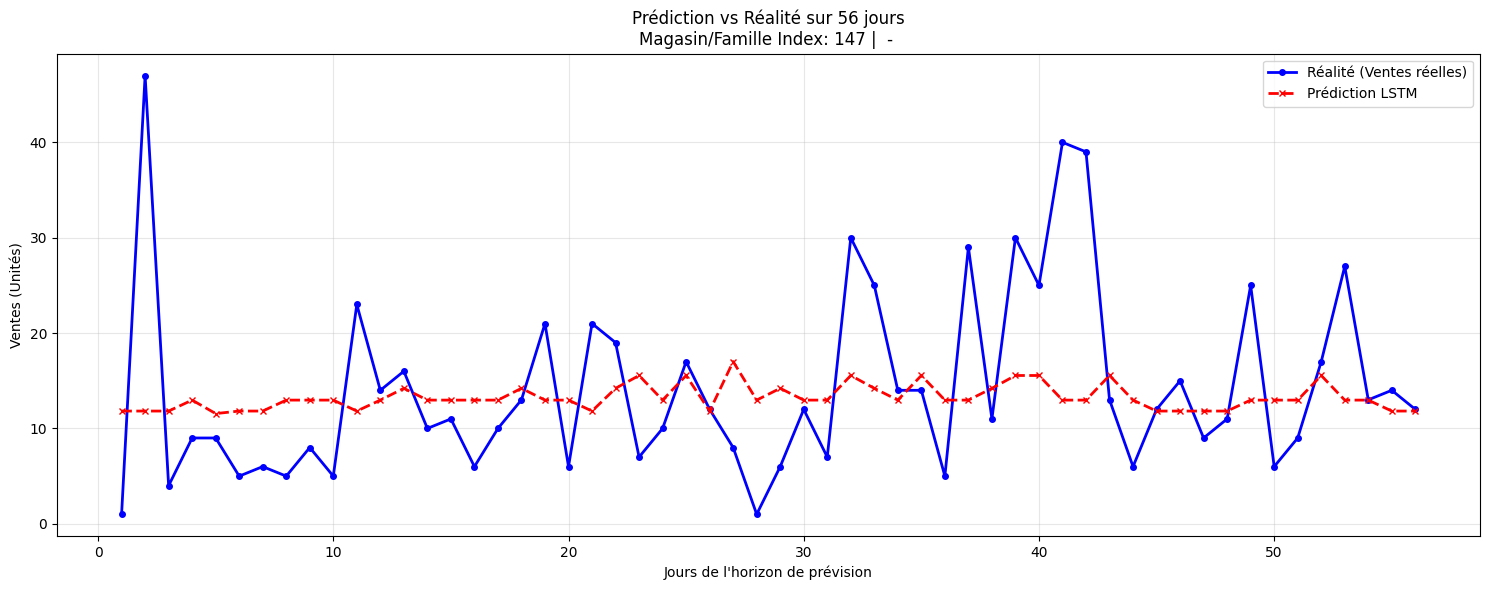

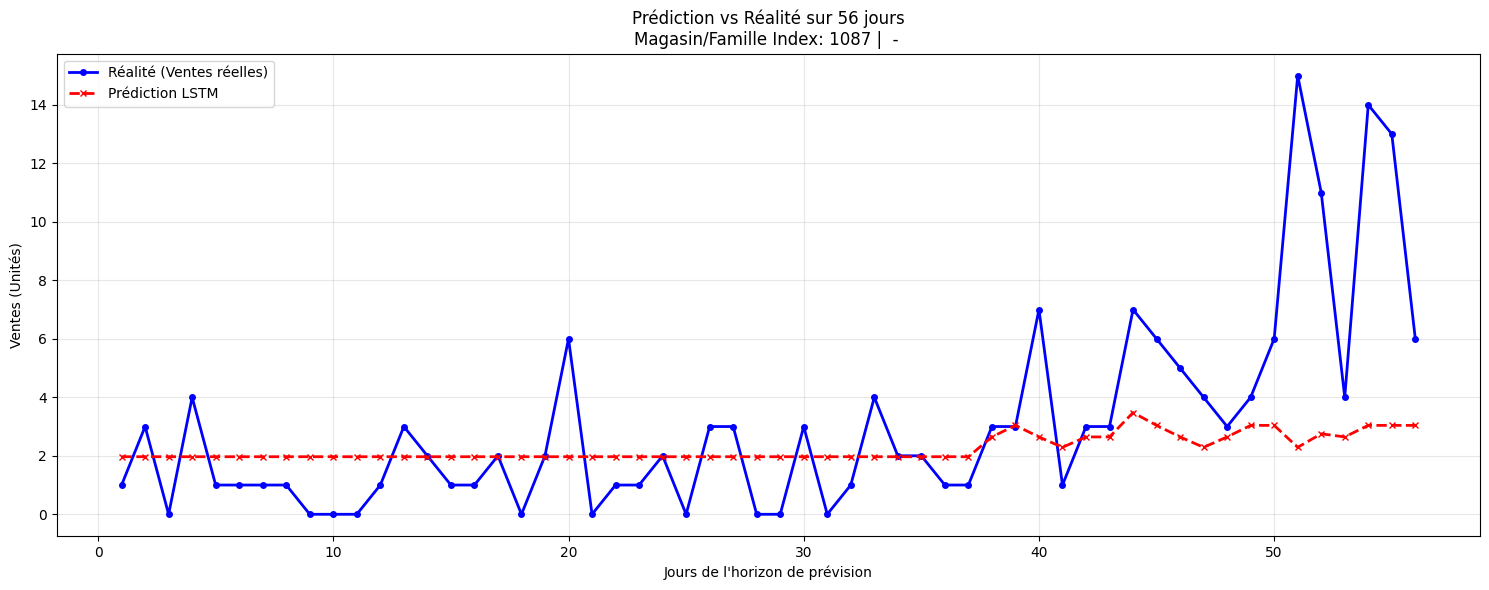

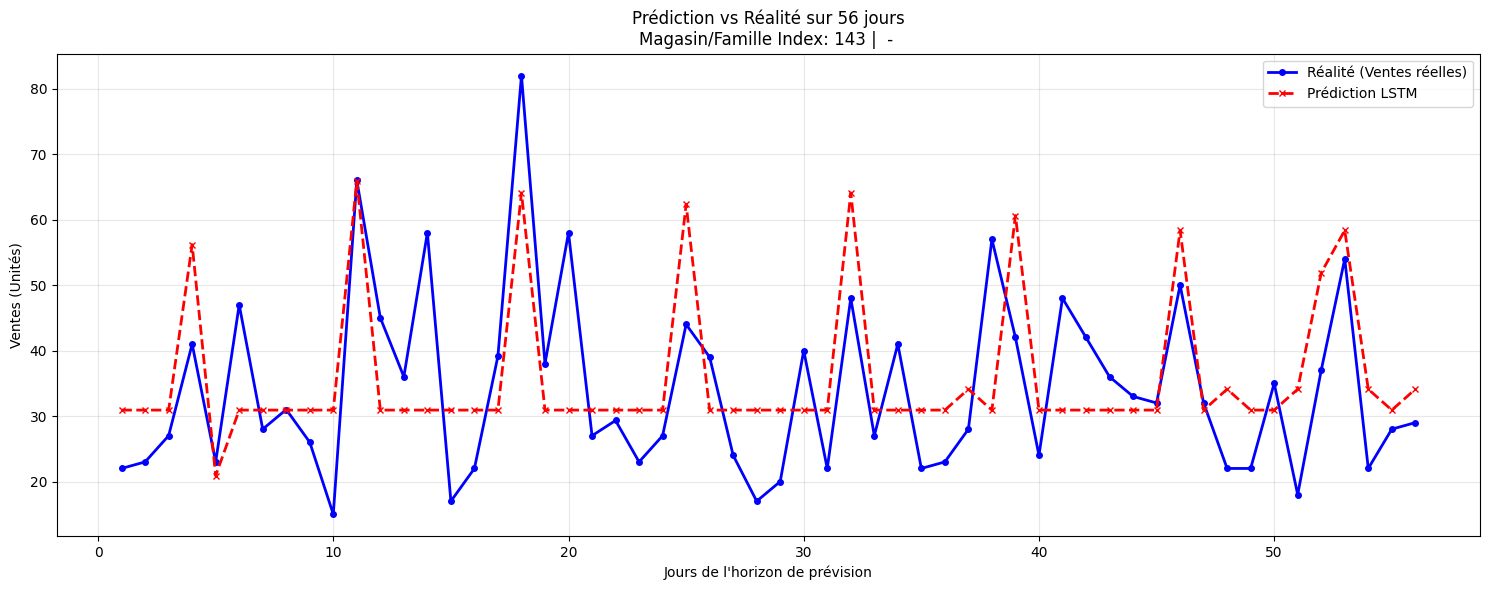

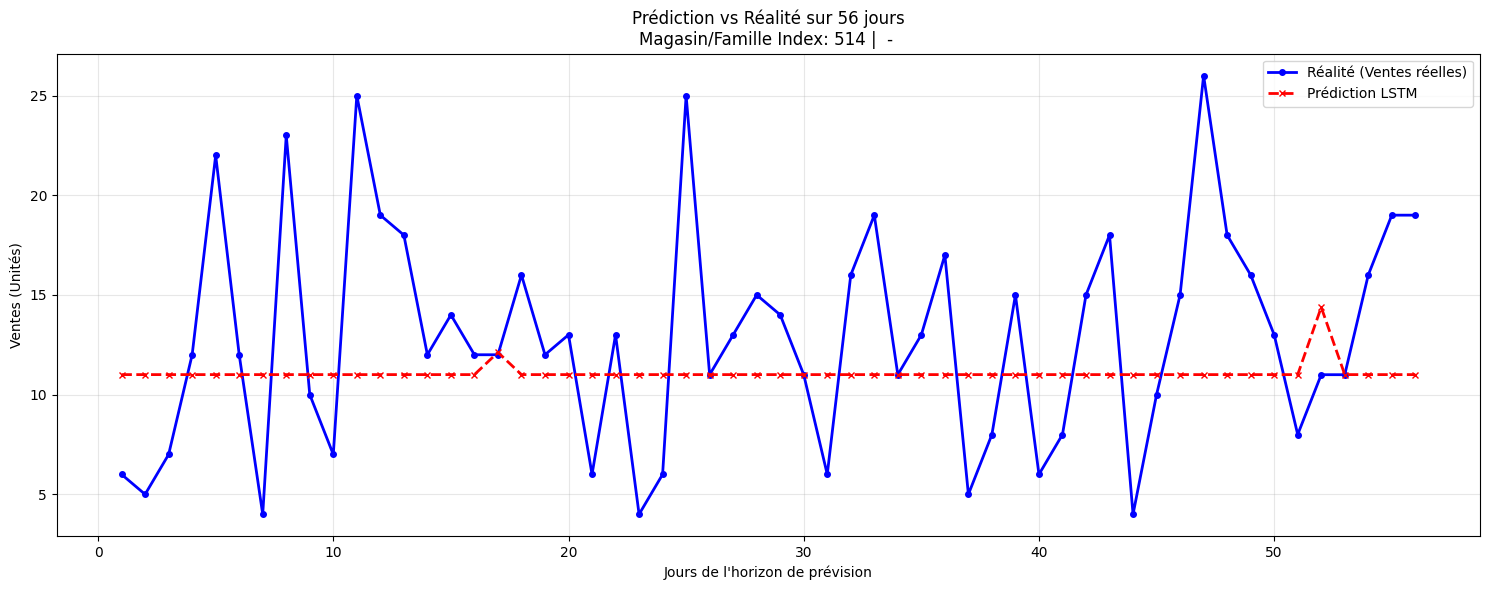

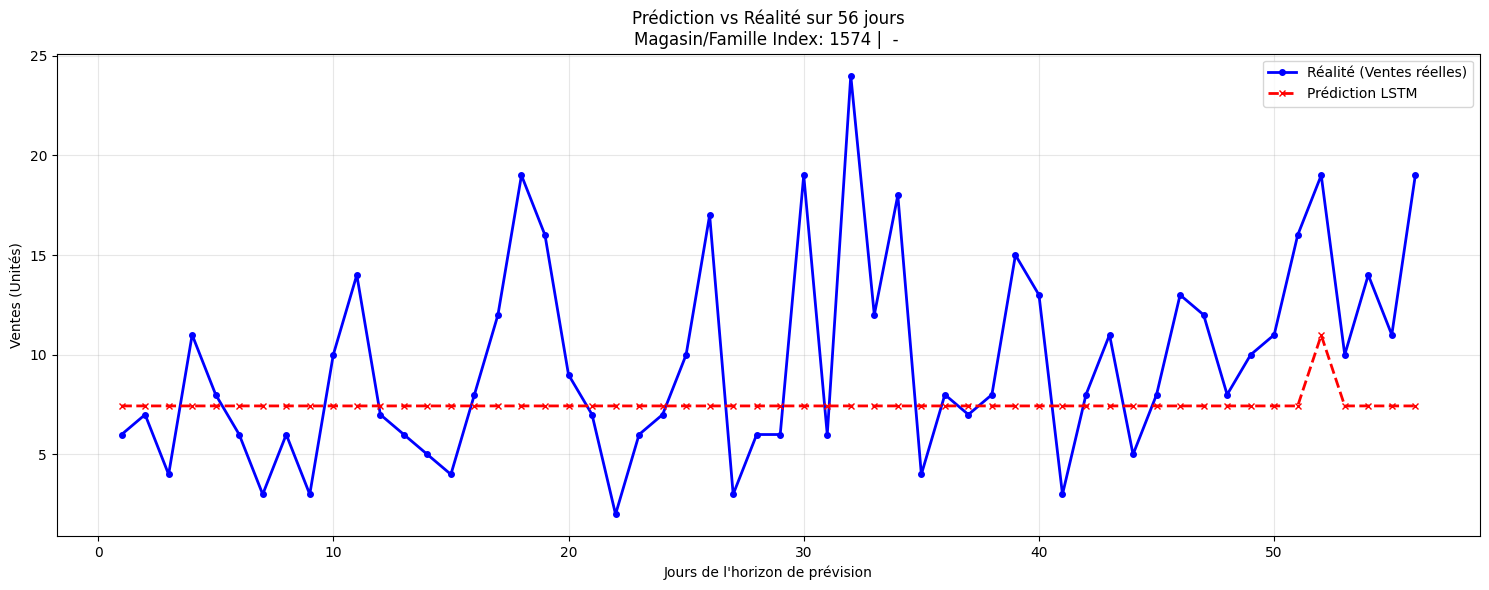

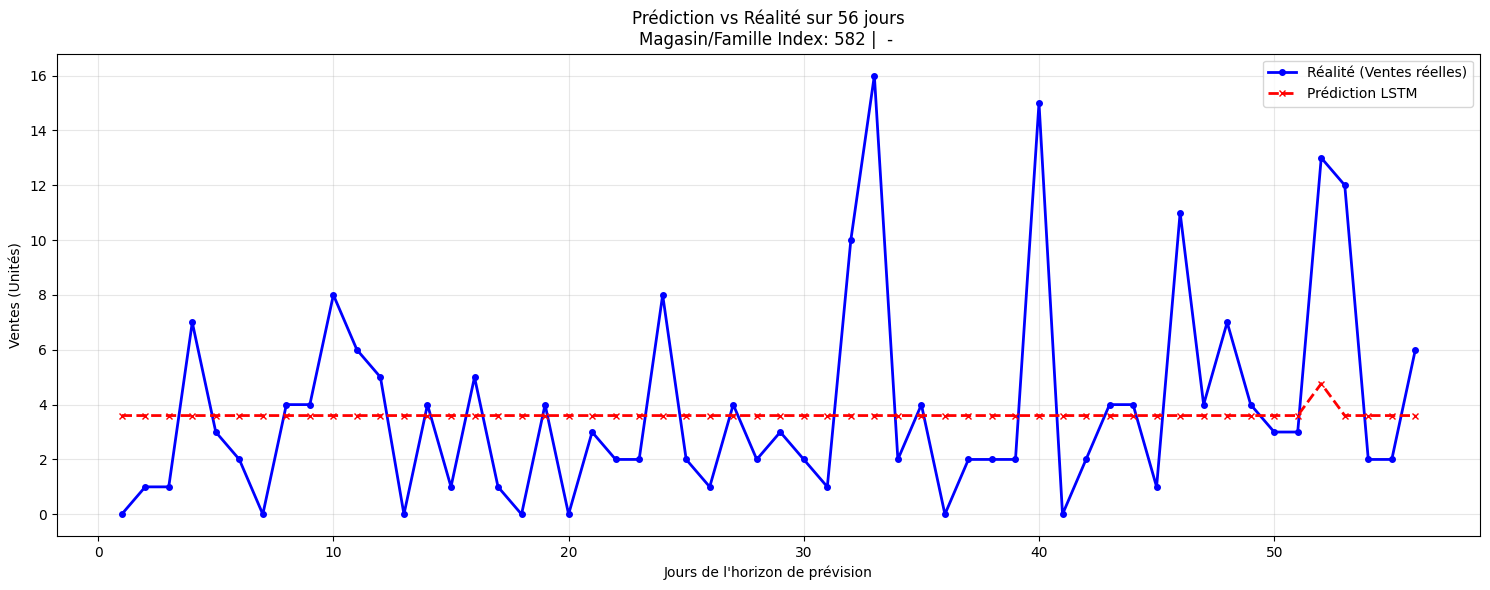

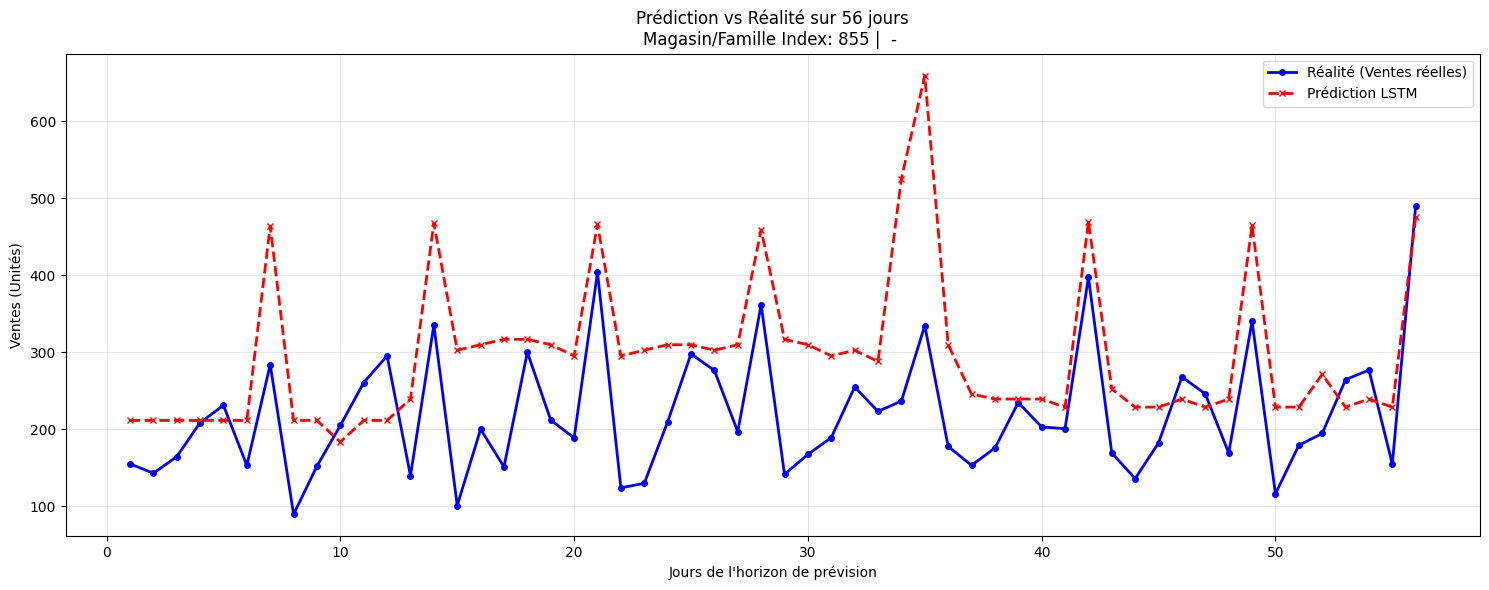

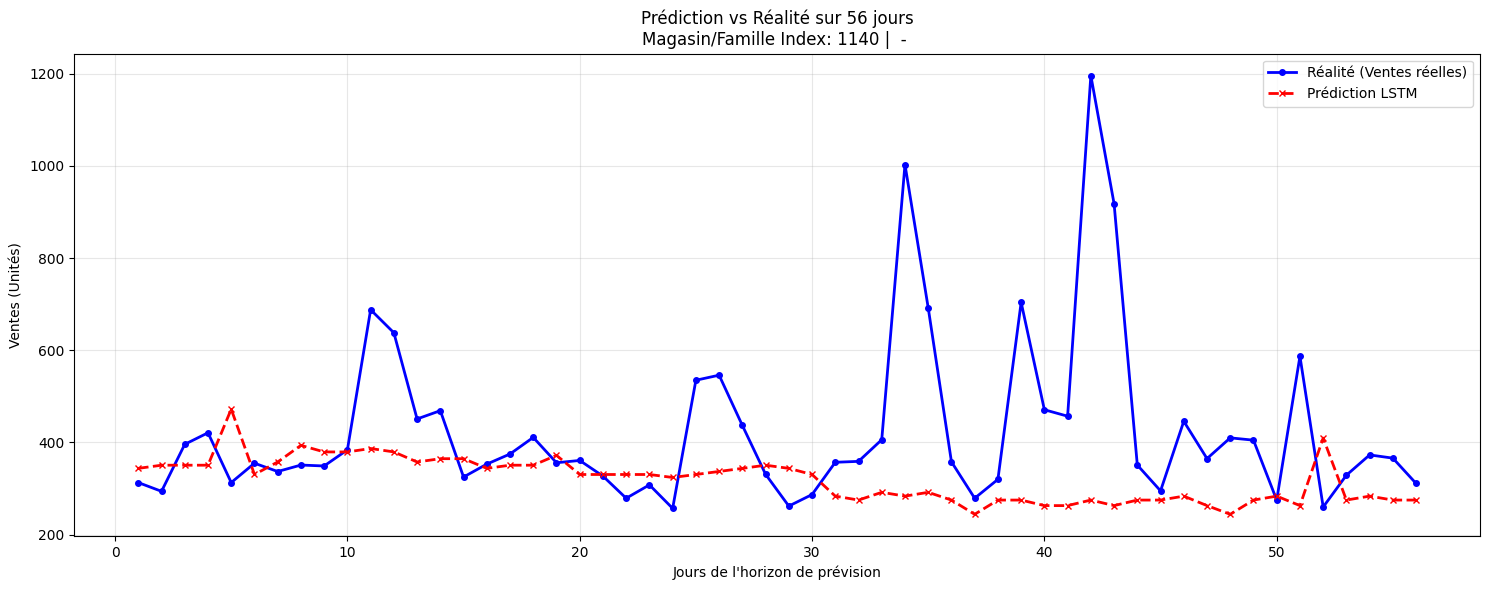

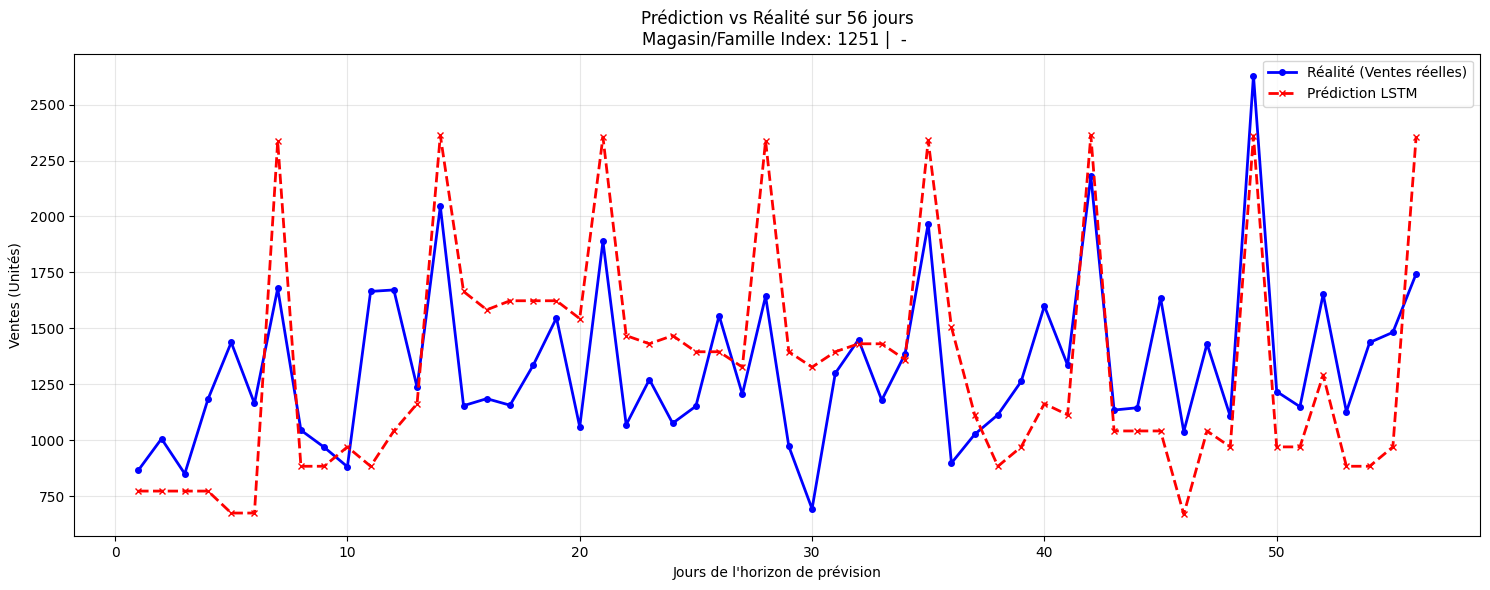

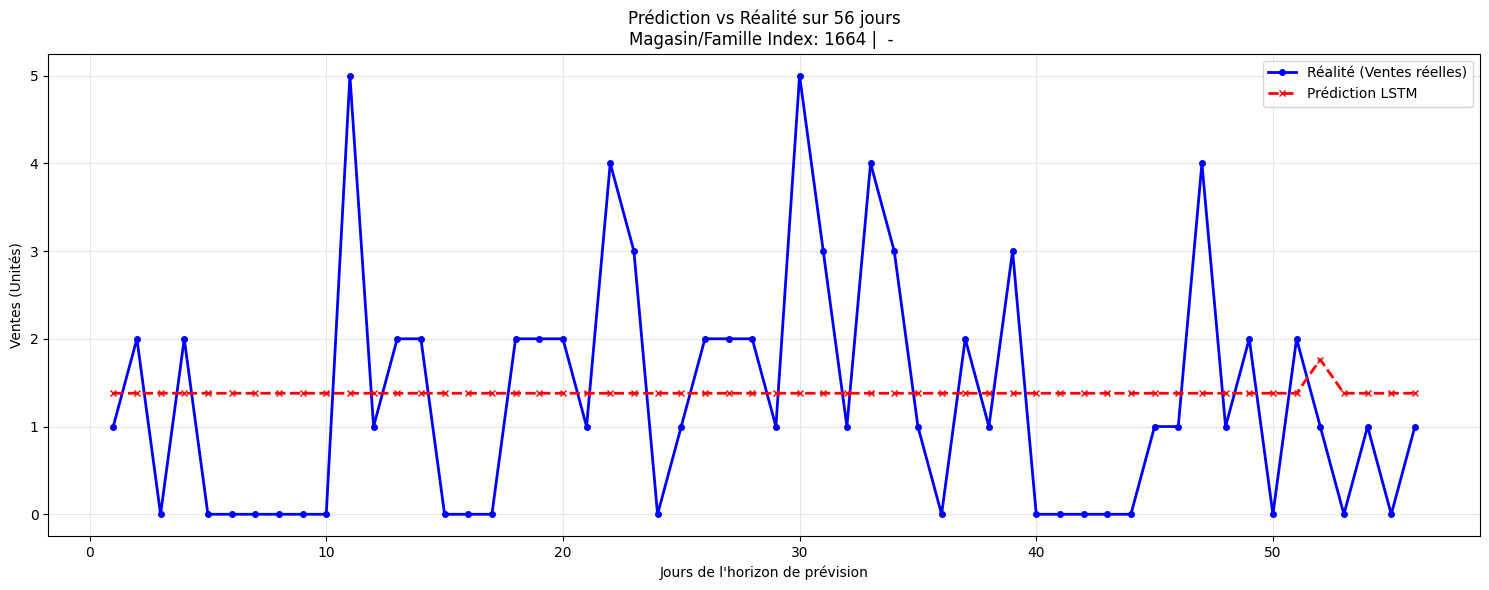

In [30]:
def plot_prediction_vs_reality(y_true, y_pred, weights, series_idx=0, store_name="", family_name=""):
    """
    Trace la comparaison entre les ventes réelles et prédites pour une série donnée.
    y_true et y_pred doivent être de forme (N_series, 56)
    """
    # Extraction des données pour la série choisie
    true_series = y_true[series_idx]
    pred_series = y_pred[series_idx]
    active_mask = weights[series_idx]

    # Création de l'axe X (56 jours)
    days = np.arange(1, 57)

    plt.figure(figsize=(15, 6))
    
    # Tracer la réalité
    plt.plot(days, true_series, label='Réalité (Ventes réelles)', color='blue', linewidth=2, marker='o', markersize=4)
    
    # Tracer la prédiction
    plt.plot(days, pred_series, label='Prédiction LSTM', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)

    # Griser les zones où le magasin était fermé (poids = 0)
    for i, active in enumerate(active_mask):
        if active == 0:
            plt.axvspan(i+1, i+1.5, color='gray', alpha=0.2)

    plt.title(f"Prédiction vs Réalité sur 56 jours\nMagasin/Famille Index: {series_idx} | {store_name} - {family_name}")
    plt.xlabel("Jours de l'horizon de prévision")
    plt.ylabel("Ventes (Unités)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Exemple de tracé pour 10 séries aléatoires
import random
for idx_to_plot in random.sample(range(0, 1701), 10):
    plot_prediction_vs_reality(
        y_test_true, 
        y_pred, 
        w_test_weights, 
        series_idx=idx_to_plot
    )


--- Affichage des 10 séries les plus fiables ---


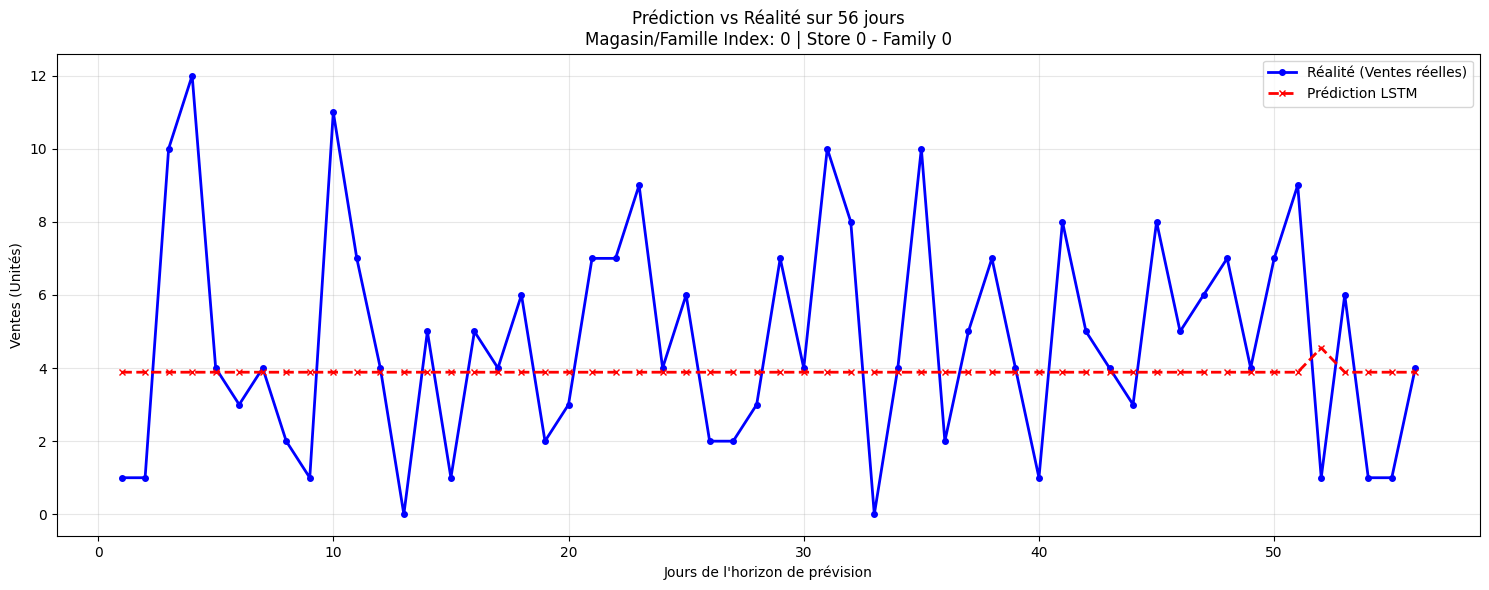

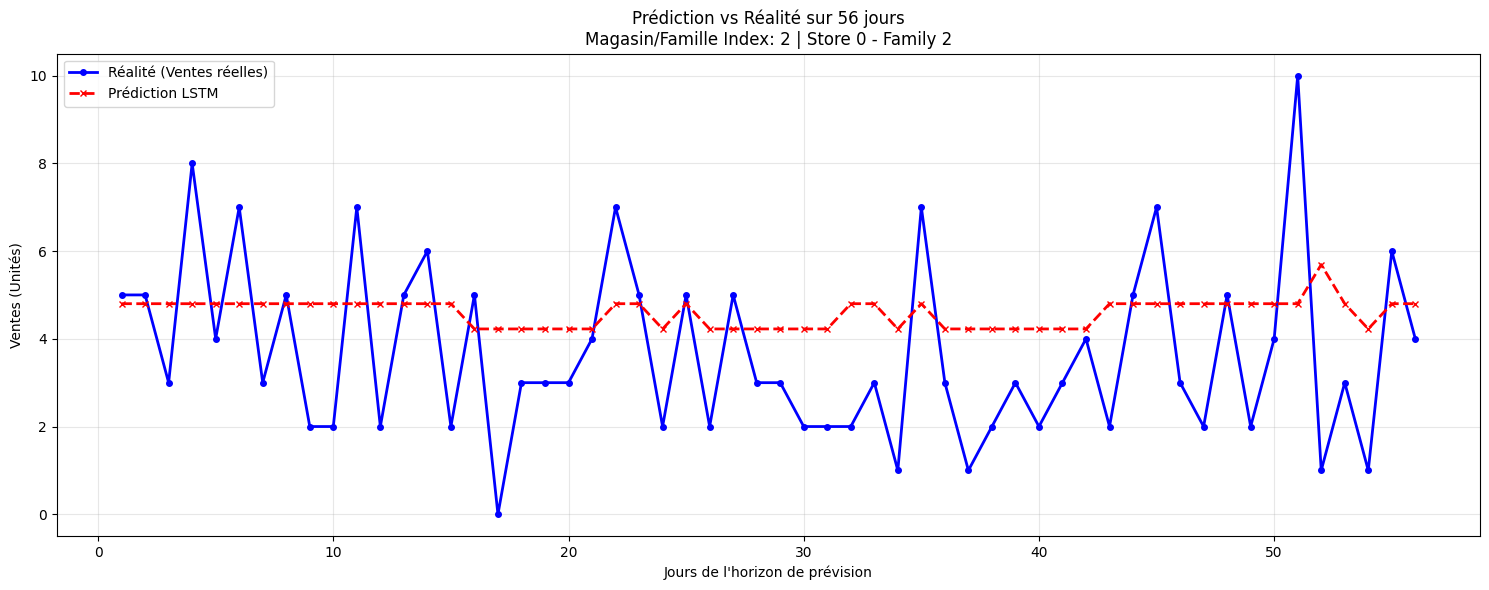

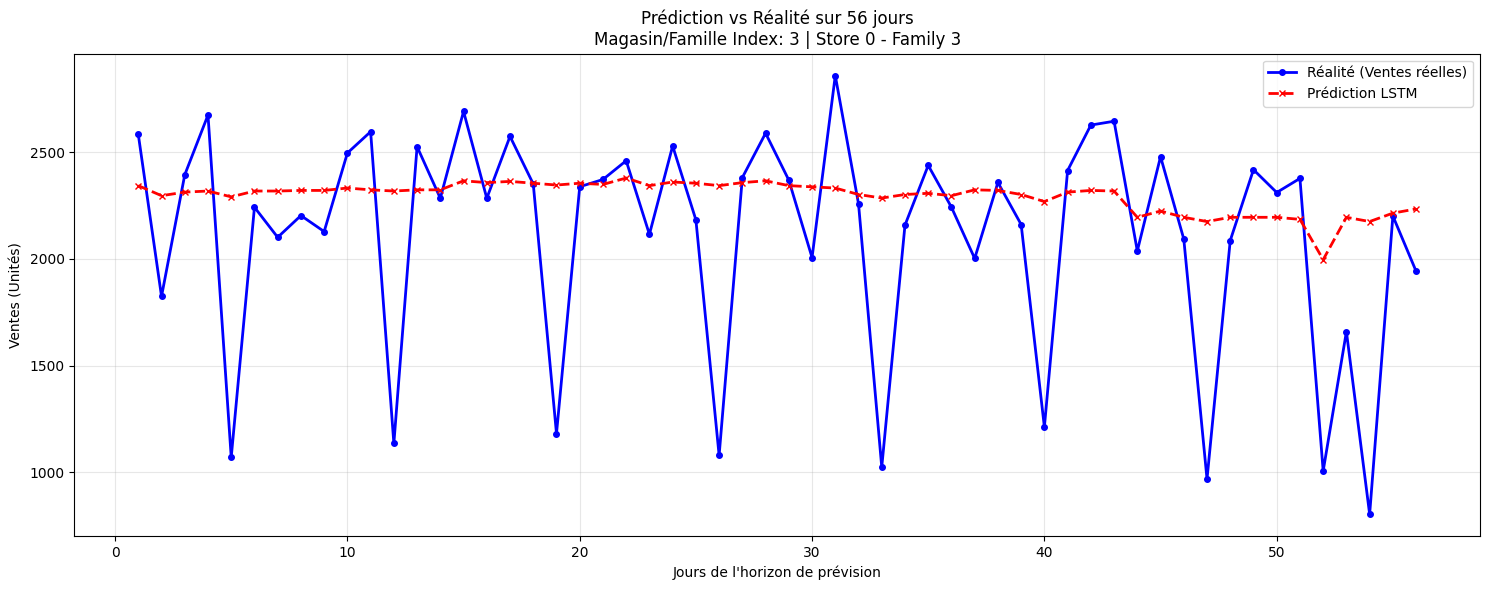

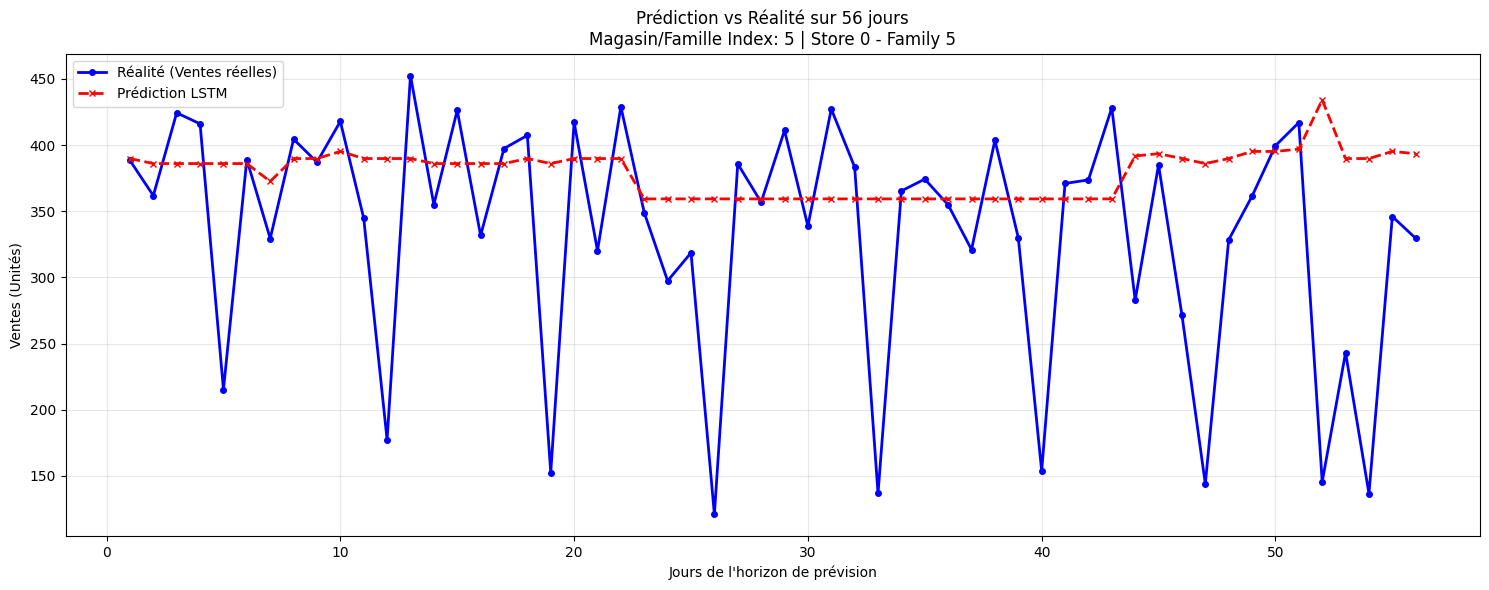

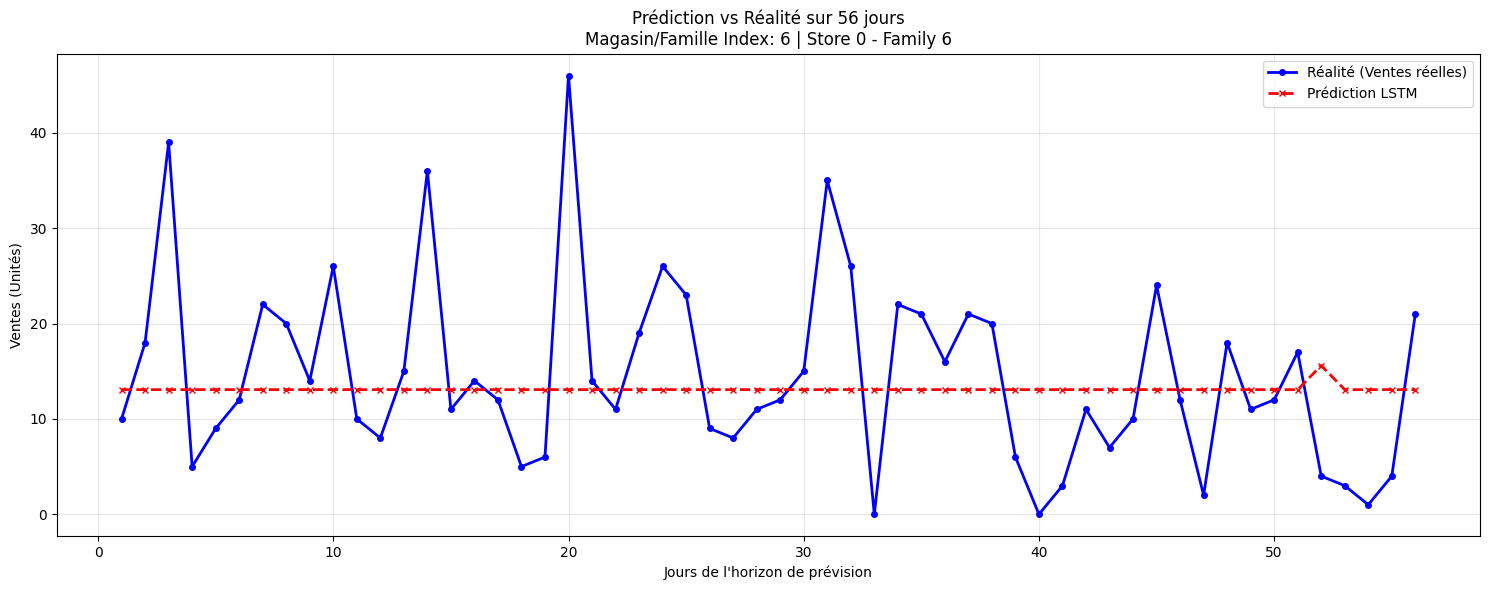

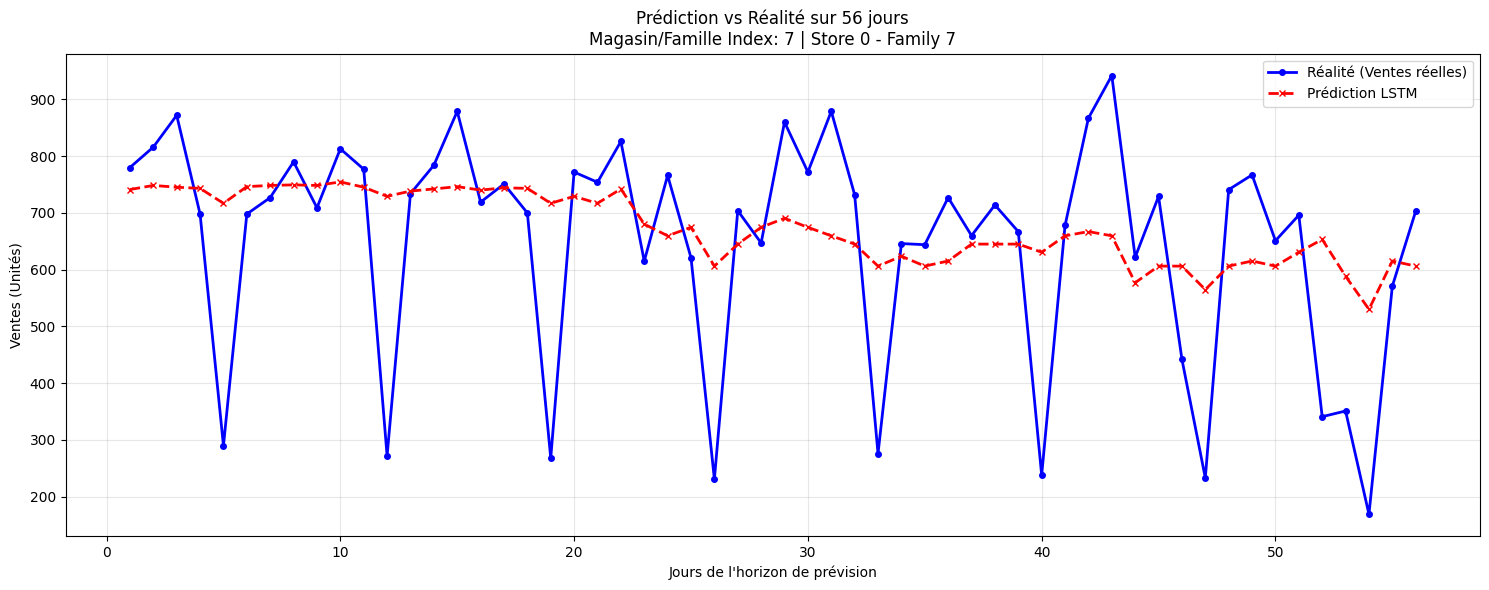

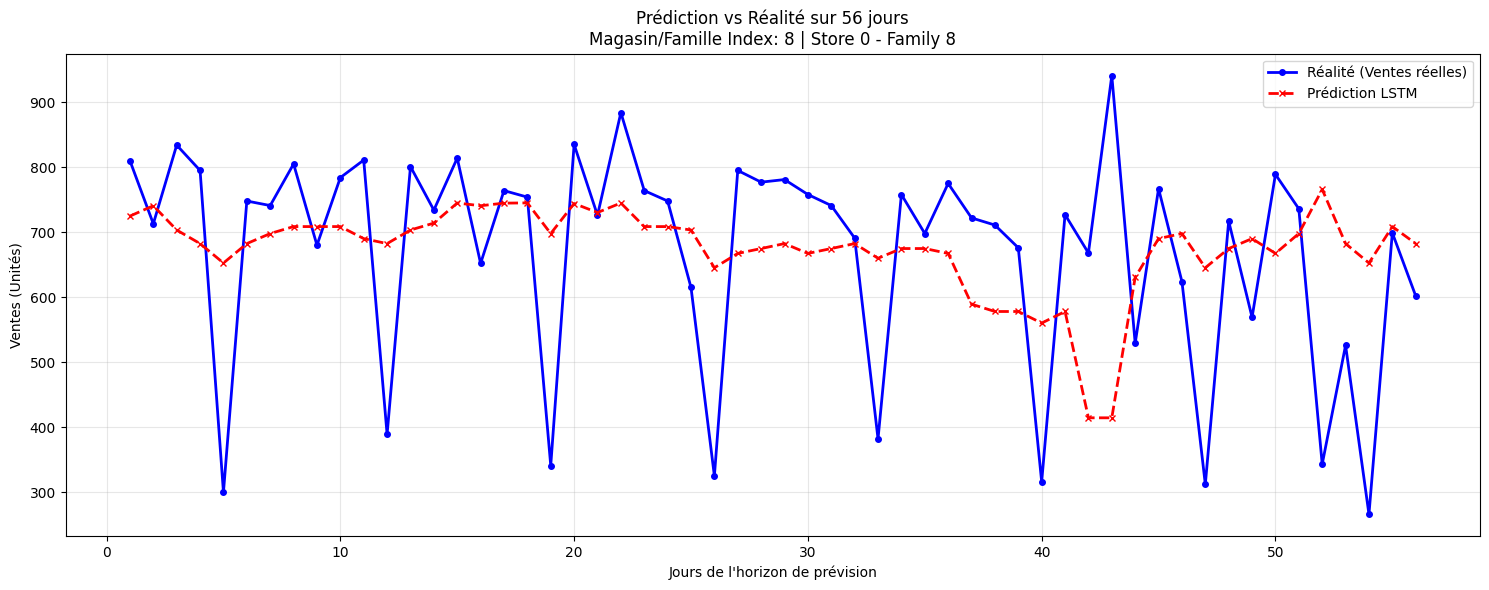

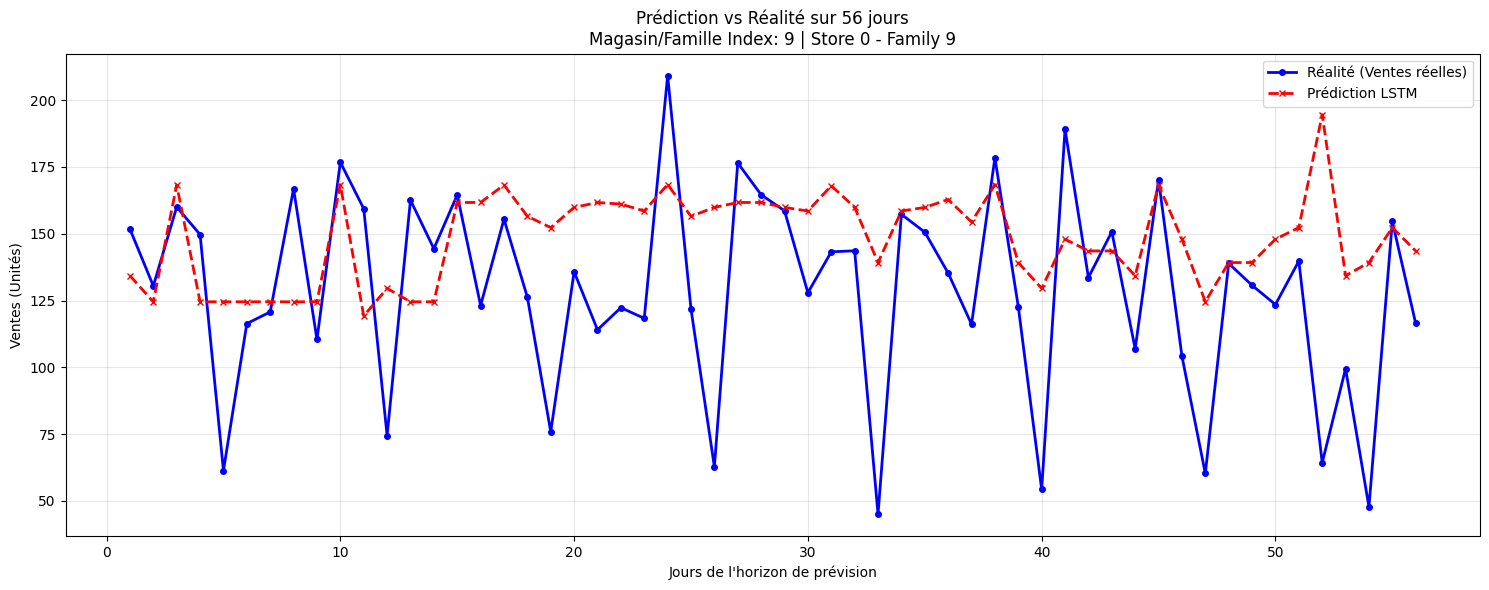

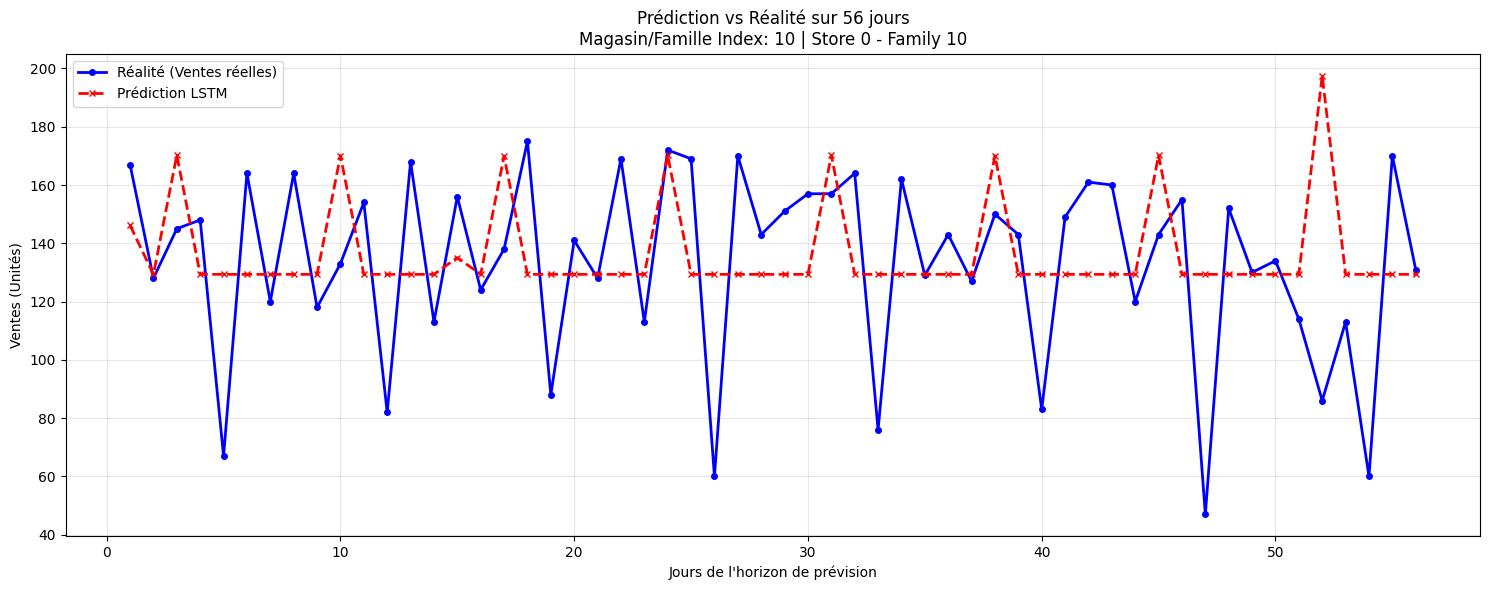

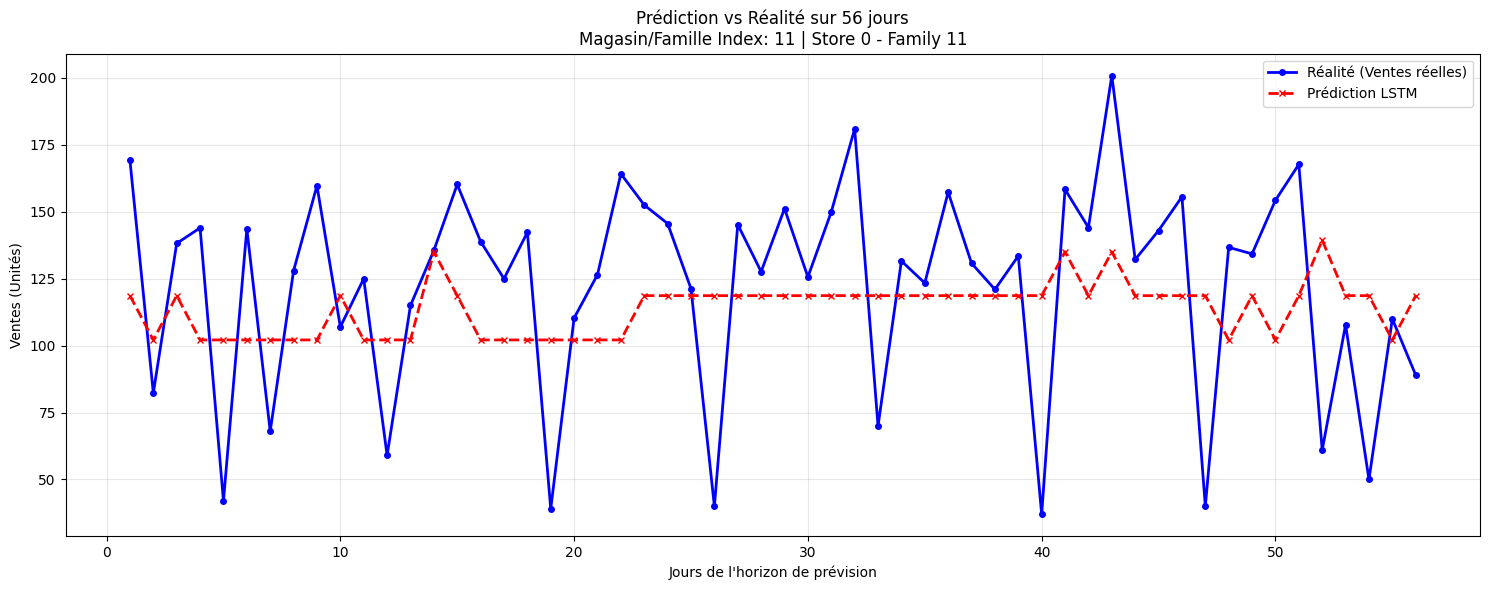

In [34]:
def get_reliable_indices(df_test_ctx, weights, n_plots=10):
    """
    df_test_ctx : le DataFrame utilisé pour générer les tenseurs de test 
                  (doit contenir 'label_store_nbr' et 'label_family')
    weights : le tenseur de poids de test (N_series, 56)
    """
    # 1. Calculer l'activité sur la période de TEST (56 jours)
    # On veut des séries SANS AUCUNE fermeture sur les 56 jours
    test_activity = np.sum(weights, axis=1)
    perfect_test_idx = np.where(test_activity == 56)[0]
    
    if len(perfect_test_idx) == 0:
        print("Aucune série 100% active en test, on prend les meilleures dispos.")
        perfect_test_idx = np.argsort(test_activity)[::-1]

    # 2. Filtrer par activité historique (TRAIN)
    # On récupère l'ordre des séries tel qu'il a été généré dans create_3d_tensors
    # (Groupby store + family)
    series_info = df_test_ctx.groupby(['label_store_nbr', 'label_family']).first().reset_index()
    
    # On ajoute le score de test à ce DataFrame pour trier
    series_info = series_info.iloc[perfect_test_idx].copy()
    series_info['tensor_idx'] = perfect_test_idx
    
    # Si tu as une colonne 'historic_activity' calculée au préalable, 
    # tu peux trier par elle ici. Sinon, on prend les premières parmi les parfaites en test.
    final_indices = series_info['tensor_idx'].head(n_plots).tolist()
    
    return final_indices

def plot_top_reliable_series(y_true, y_pred, weights, df_test_ctx, n_plots=10):
    # Récupération des indices fiables
    indices = get_reliable_indices(df_test_ctx, weights, n_plots)
    
    # Mapping pour retrouver les noms (si tu as les dictionnaires d'encodage)
    # series_info nous donne les labels originaux pour chaque index du tenseur
    mapping = df_test_ctx.groupby(['label_store_nbr', 'label_family']).first().reset_index()

    print(f"--- Affichage des {len(indices)} séries les plus fiables ---")
    
    for idx in indices:
        store_label = mapping.iloc[idx]['label_store_nbr']
        family_label = mapping.iloc[idx]['label_family']
        
        # Appel de ta fonction de plot d'origine
        plot_prediction_vs_reality(
            y_true, 
            y_pred, 
            weights, 
            series_idx=idx,
            store_name=f"Store {store_label}",
            family_name=f"Family {family_label}"
        )

# Utilisation
plot_top_reliable_series(y_test_true, y_pred, w_test_weights, df_val_ctx, n_plots=10)

feature importance 

Calcul de l'importance pour les variables passées...
Calcul de l'importance pour les variables futures...


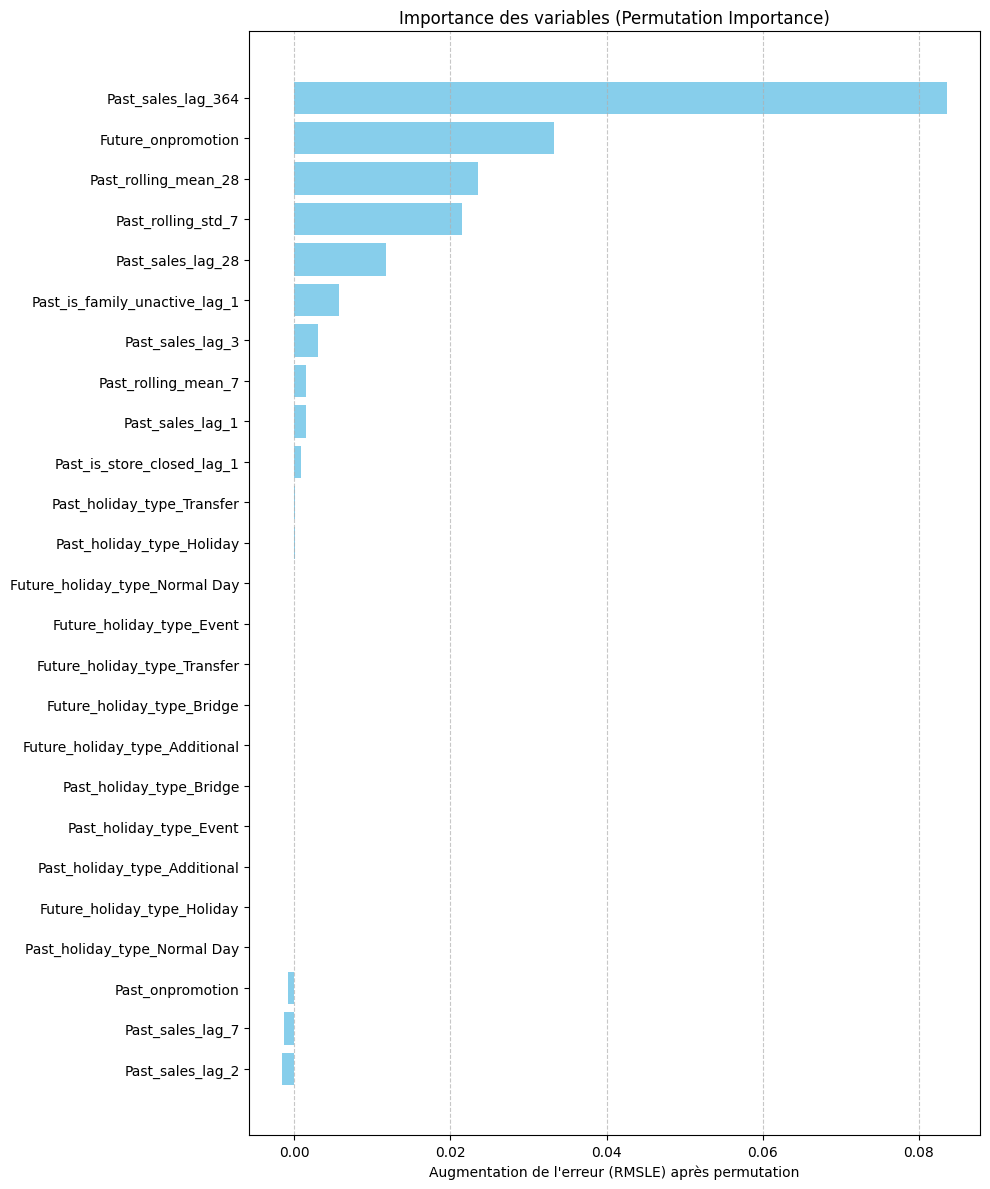

In [35]:
def plot_lstm_feature_importance(model, X_list, y_true, w_weights, cols_past, cols_future):
    # Calculer le score de base (Baseline)
    y_pred_base = model.predict(X_list, verbose=0)
    baseline_metrics = evaluate_model_simple(y_true.flatten(), y_pred_base.flatten(), w_weights.flatten())
    baseline_score = baseline_metrics['rmsle']
    
    importance_results = {}
    
    # Importance pour les variables du PASSÉ (Input 0)
    print("Calcul de l'importance pour les variables passées...")
    for i, col in enumerate(cols_past):
        X_temp = [np.copy(x) for x in X_list]
        # On mélange les données de la colonne i sur l'axe du temps
        save_col = X_temp[0][:, :, i].copy()
        np.random.shuffle(X_temp[0][:, :, i])
        
        y_pred = model.predict(X_temp, verbose=0)
        score = evaluate_model_simple(y_true.flatten(), y_pred.flatten(), w_weights.flatten())['rmsle']
        importance_results[f"Past_{col}"] = score - baseline_score
        
    # Importance pour les variables du FUTUR (Input 1)
    print("Calcul de l'importance pour les variables futures...")
    for i, col in enumerate(cols_future):
        X_temp = [np.copy(x) for x in X_list]
        np.random.shuffle(X_temp[1][:, :, i])
        
        y_pred = model.predict(X_temp, verbose=0)
        score = evaluate_model_simple(y_true.flatten(), y_pred.flatten(), w_weights.flatten())['rmsle']
        importance_results[f"Future_{col}"] = score - baseline_score

    # Création du Plot
    df_importance = pd.DataFrame(list(importance_results.items()), columns=['Feature', 'Importance'])
    df_importance = df_importance.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(10, 12))
    plt.barh(df_importance['Feature'], df_importance['Importance'], color='skyblue')
    plt.xlabel('Augmentation de l\'erreur (RMSLE) après permutation')
    plt.title('Importance des variables (Permutation Importance)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


cols_past = ['onpromotion', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
    'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
    'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1'] + holiday_cols

cols_future = ['onpromotion'] + holiday_cols

plot_lstm_feature_importance(final_model, X_val_list, y_val_3d, w_val_3d, cols_past, cols_future)

Feature importance du LSTM avec toutes les variables (issu d'un code précédent)

Calcul de l'importance pour les variables passées...
Calcul de l'importance pour les variables futures...


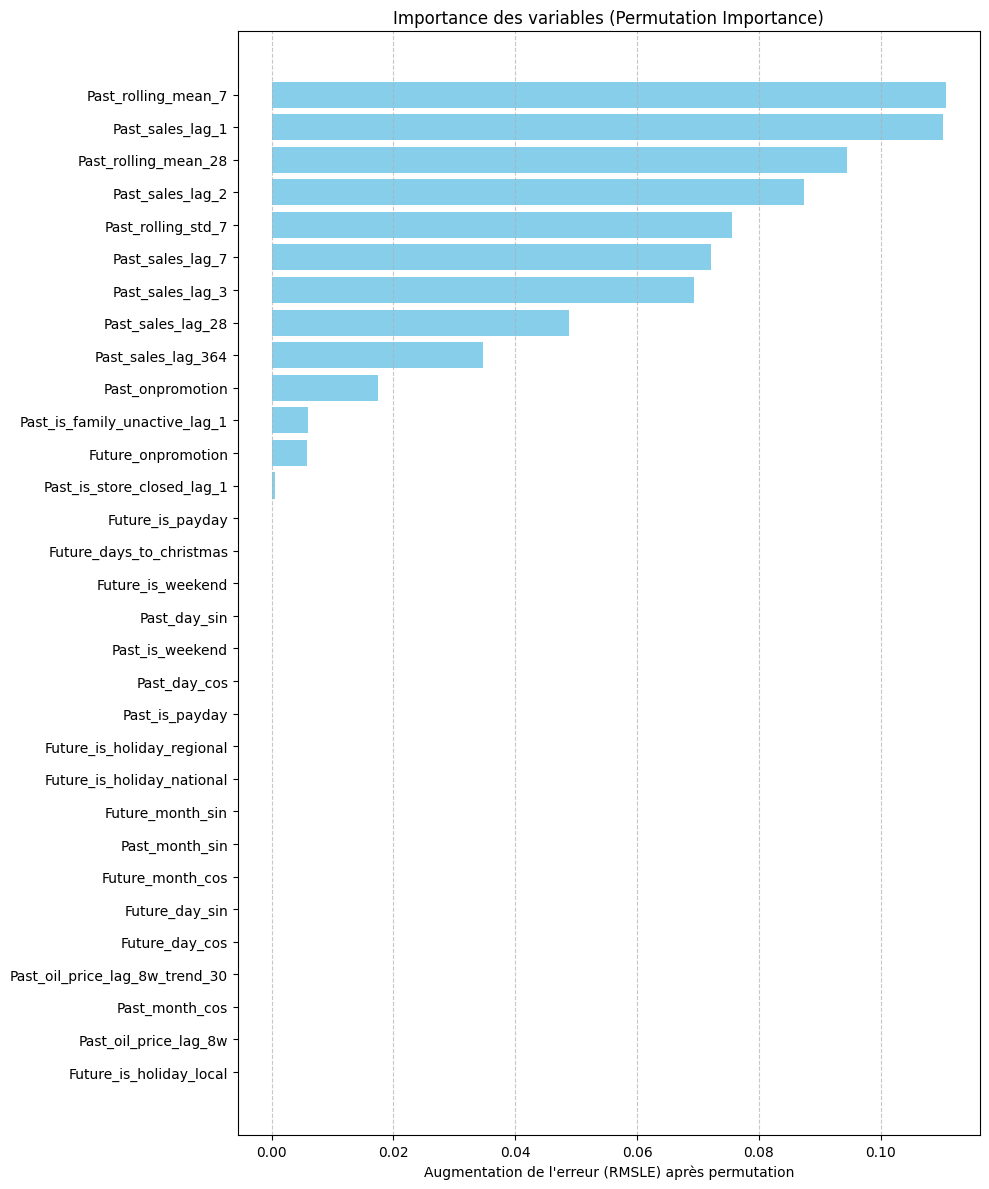

: 

In [ ]:
cols_past = [
    'onpromotion', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30',
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_7', 
    'sales_lag_28', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_28', 
    'rolling_std_7', 'is_store_closed_lag_1', 'is_family_unactive_lag_1',
    'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend', 'is_payday'
]
cols_future = [
    'onpromotion', 'is_holiday_local', 'is_holiday_regional', 
    'is_holiday_national', 'month_sin', 'month_cos', 'day_sin', 
    'day_cos', 'is_weekend', 'is_payday', 'days_to_christmas'
]

plot_lstm_feature_importance(final_model, X_val_list, y_val_3d, w_val_3d, cols_past, cols_future)

Au vu de ces résultats on peut essayer de diminuer le nombre de variables en entrée du modèle. 

Conclusion : trop peu de points et des séries trop variables ce qui n'est pas adapté pour LSTM. On aurait pu tester un LSTM classique mais cela aurait surement été trop instable au vu des séries. 